# Week 9: Gradint Boosting

## 1. Notebook Setup
- Import libraries

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook", font_scale=1.1)


## 2. Dataset 1: customer_churn
### 2.1 Data Overview & Preparation

In [34]:
#load data
train_cc = pd.read_csv('customer_churn_dataset-training-master.csv')
test_cc = pd.read_csv('customer_churn_dataset-testing-master.csv')
#combine train and test set
customer_churn = pd.concat([train_cc, test_cc], ignore_index=True)
#drop null rows
customer_churn.dropna(inplace=True)
#drop CustomerID col (irrelevant)
customer_churn = customer_churn.drop('CustomerID', axis=1)
sample, _ = train_test_split(
    customer_churn,
    train_size = 0.3, #use 30% of dataset
    stratify = customer_churn['Churn'],
    random_state = 42
)
#preprocessing:
target_col = "Churn"
def preprocess(df, target_col):
    X = pd.get_dummies(df.drop(target_col, axis=1), drop_first=True)
    y = df[target_col]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X, X_scaled, y
X_cc, X_cc_scaled, y_cc = preprocess(sample, target_col)

### 2.2 Gradient Boosting

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_cc_scaled, y_cc, test_size=0.2, random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0]
}
gb_cv = GridSearchCV(GradientBoostingClassifier(), param_grid, cv=5, n_jobs=-1)
gb_cv.fit(X_train, y_train)

print("Best Parameters:", gb_cv.best_params_)
print("Best CV Score:", gb_cv.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}
Best CV Score: 0.9262998214827011


In [4]:
y_pred = gb_cv.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

         0.0       0.94      0.92      0.93     13437
         1.0       0.93      0.95      0.94     16876

    accuracy                           0.94     30313
   macro avg       0.94      0.93      0.93     30313
weighted avg       0.94      0.94      0.94     30313



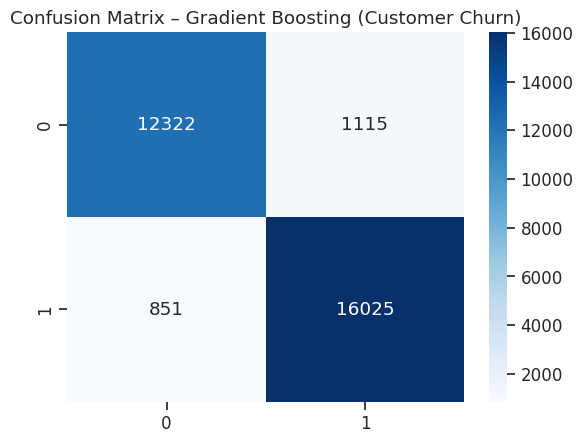

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='g')
plt.title("Confusion Matrix: Gradient Boosting (Customer Churn)")
plt.show()

### 2.3: Learning Rate & Estimator Tradeoff

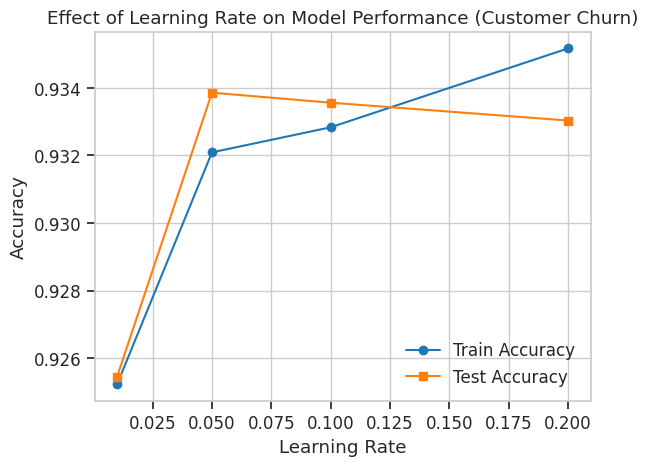

In [6]:
learning_rates = [0.01, 0.05, 0.1, 0.2]
train_scores, test_scores = [], []

for lr in learning_rates:
    gb = GradientBoostingClassifier(n_estimators=100, learning_rate=lr, max_depth=3, random_state=42)
    gb.fit(X_train, y_train)
    train_scores.append(gb.score(X_train, y_train))
    test_scores.append(gb.score(X_test, y_test))

plt.plot(learning_rates, train_scores, label="Train Accuracy", marker="o")
plt.plot(learning_rates, test_scores, label="Test Accuracy", marker="s")
plt.title("Effect of Learning Rate on Model Performance (Customer Churn)")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### 2.4: Feature Importance

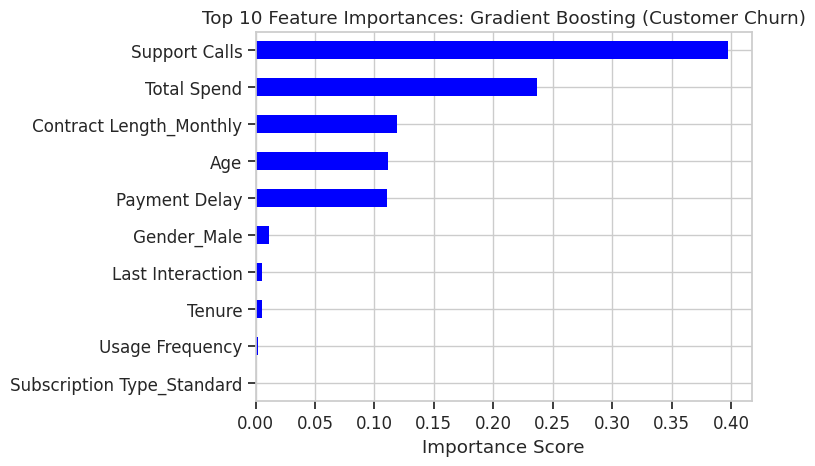

In [40]:
best_model = gb_cv.best_estimator_

feature_importances = pd.Series(best_model.feature_importances_, index=X_cc.columns[:len(best_model.feature_importances_)])
top_features = feature_importances.sort_values(ascending=True).tail(10)

top_features.plot(kind='barh', color='blue')
plt.title("Top 10 Feature Importances: Gradient Boosting (Customer Churn)")
plt.xlabel("Importance Score")
plt.show()

#### Additional plots:
[insert any plots]

## 3. Dataset 2: digital_marketing_campaign

In [44]:
digital_marketing = pd.read_csv("digital_marketing_campaign_dataset.csv")
digital_marketing = digital_marketing.drop('CustomerID', axis=1)
X = pd.get_dummies(digital_marketing.drop("Conversion", axis=1, errors="ignore"), drop_first=True)
y = digital_marketing["Conversion"] if "Conversion" in digital_marketing.columns else None

X_dm, X_dm_scaled, y_dm = preprocess(digital_marketing, 'Conversion')

### 3.1 Gradient Boosting

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X_dm_scaled, y_dm, test_size=0.2, random_state=42)
param_grid_reg = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0],
    'loss': ['squared_error', 'absolute_error']
}
gb_reg_cv = GridSearchCV(GradientBoostingRegressor(), param_grid_reg, cv=5, n_jobs=-1)
gb_reg_cv.fit(X_train, y_train)

print("Best Parameters:", gb_reg_cv.best_params_)
print("Best CV Score:", gb_reg_cv.best_score_)

Best Parameters: {'learning_rate': 0.05, 'loss': 'squared_error', 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV Score: 0.3131188573944944


In [49]:
y_pred = gb_reg_cv.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
print(f"Test RMSE: {rmse:.4f}")

Test RMSE: 0.2720


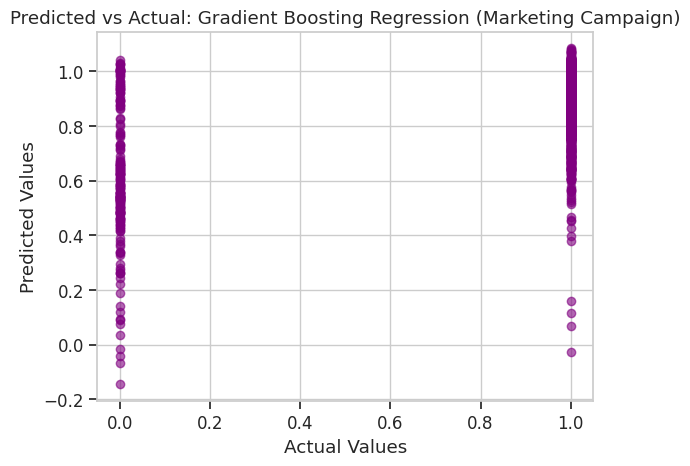

In [51]:
plt.scatter(y_test, y_pred, alpha=0.6, color='purple')
plt.title("Predicted vs Actual: Gradient Boosting Regression (Marketing Campaign)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

### 3.3: Learning Rate & Estimator Tradeoff

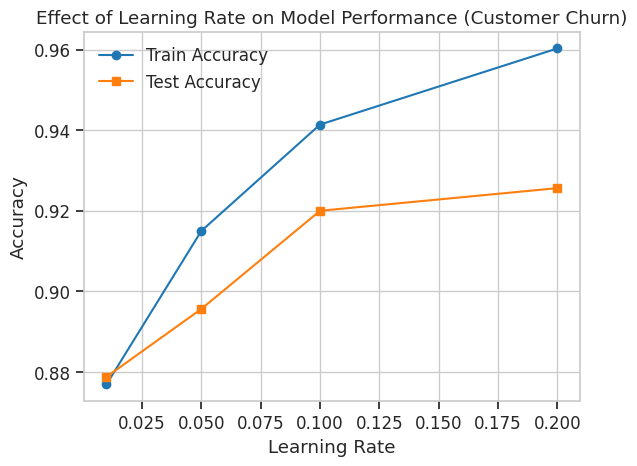

In [52]:
learning_rates = [0.01, 0.05, 0.1, 0.2]
train_scores, test_scores = [], []

for lr in learning_rates:
    gb = GradientBoostingClassifier(n_estimators=100, learning_rate=lr, max_depth=3, random_state=42)
    gb.fit(X_train, y_train)
    train_scores.append(gb.score(X_train, y_train))
    test_scores.append(gb.score(X_test, y_test))

plt.plot(learning_rates, train_scores, label="Train Accuracy", marker="o")
plt.plot(learning_rates, test_scores, label="Test Accuracy", marker="s")
plt.title("Effect of Learning Rate on Model Performance (Customer Churn)")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### 3.4: Feature Importance

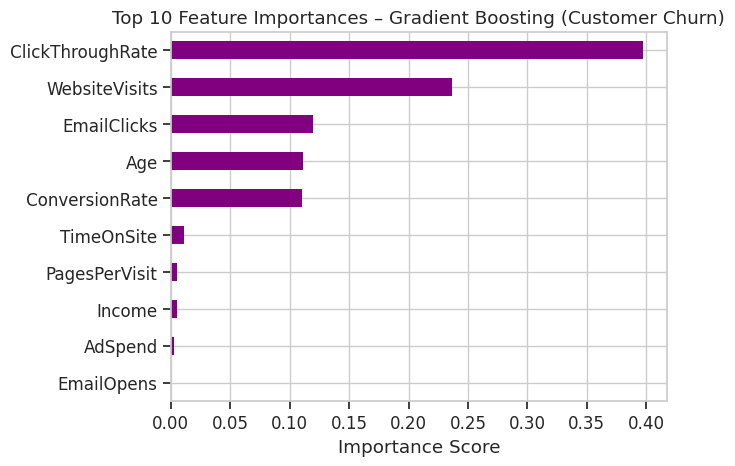

In [57]:
best_model = gb_cv.best_estimator_
feature_importances = pd.Series(best_model.feature_importances_, index=X_dm.columns[:len(best_model.feature_importances_)])
top_features = feature_importances.sort_values(ascending=True).tail(10)

top_features.plot(kind='barh', color='purple')
plt.title("Top 10 Feature Importances – Gradient Boosting (Customer Churn)")
plt.xlabel("Importance Score")
plt.show()

## 4. Dataset 3: marketing_campaign

In [64]:
marketing_campaign = pd.read_csv("marketing_campaign.csv", sep=';')
marketing_campaign = marketing_campaign.drop('ID', axis=1) #drop ID col irrelevant
marketing_campaign.dropna(inplace=True) #drop null cols
X = pd.get_dummies(marketing_campaign.drop("Response", axis=1, errors="ignore"), drop_first=True)
y = marketing_campaign["Response"] if "Response" in marketing_campaign.columns else None

X_mc, X_mc_scaled, y_mc = preprocess(marketing_campaign, 'Response')

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X_mc_scaled, y_mc, test_size=0.2, random_state=42)
param_grid_reg = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0],
    'loss': ['squared_error', 'absolute_error']
}
gb_reg_cv = GridSearchCV(GradientBoostingRegressor(), param_grid_reg, cv=5, n_jobs=-1)
gb_reg_cv.fit(X_train, y_train)

print("Best Parameters:", gb_reg_cv.best_params_)
print("Best CV Score:", gb_reg_cv.best_score_)

Best Parameters: {'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 4, 'n_estimators': 50, 'subsample': 1.0}
Best CV Score: 0.3037429804815863


In [66]:
y_pred = gb_reg_cv.predict(X_test)
rmse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
print(f"Test RMSE: {rmse:.4f}")

Test RMSE: 0.2720


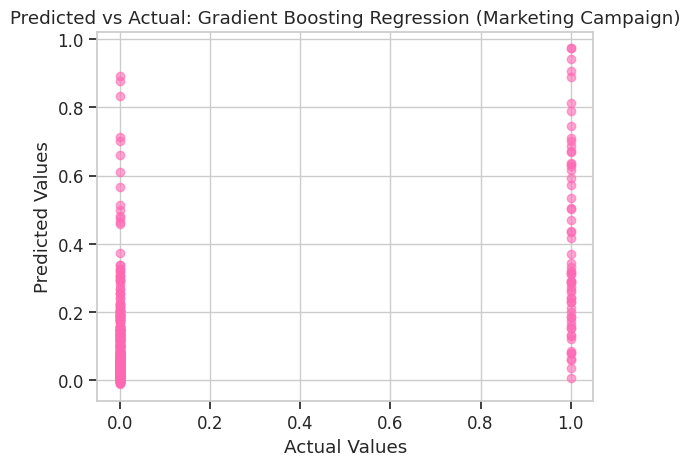

In [68]:
plt.scatter(y_test, y_pred, alpha=0.6, color='hotpink')
plt.title("Predicted vs Actual: Gradient Boosting Regression (Marketing Campaign)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

### 4.3: Learning Rate & Estimator Tradeoff

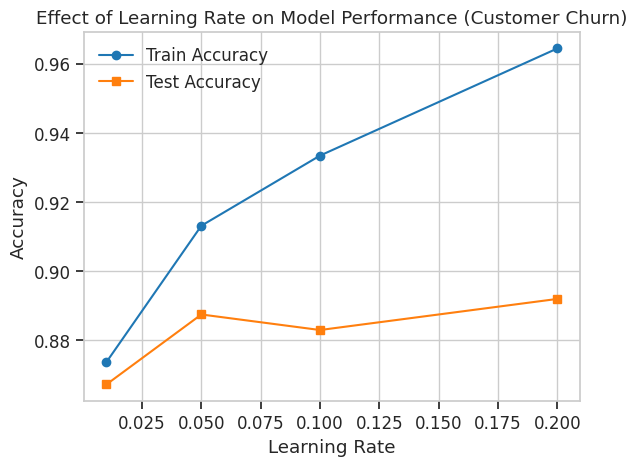

In [69]:
learning_rates = [0.01, 0.05, 0.1, 0.2]
train_scores, test_scores = [], []

for lr in learning_rates:
    gb = GradientBoostingClassifier(n_estimators=100, learning_rate=lr, max_depth=3, random_state=42)
    gb.fit(X_train, y_train)
    train_scores.append(gb.score(X_train, y_train))
    test_scores.append(gb.score(X_test, y_test))

plt.plot(learning_rates, train_scores, label="Train Accuracy", marker="o")
plt.plot(learning_rates, test_scores, label="Test Accuracy", marker="s")
plt.title("Effect of Learning Rate on Model Performance (Customer Churn)")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### 4.4: Feature Importance

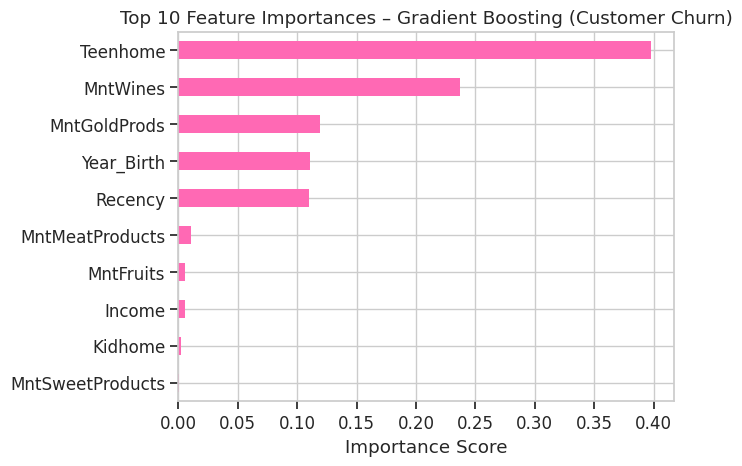

In [70]:
best_model = gb_cv.best_estimator_
feature_importances = pd.Series(best_model.feature_importances_, index=X_mc.columns[:len(best_model.feature_importances_)])
top_features = feature_importances.sort_values(ascending=True).tail(10)

top_features.plot(kind='barh', color='hotpink')
plt.title("Top 10 Feature Importances – Gradient Boosting (Customer Churn)")
plt.xlabel("Importance Score")
plt.show()